<a href="https://colab.research.google.com/github/baochay/DoAn2_TH-DeepLearning/blob/main/DoAn2_Nhom1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Khai báo thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

print("Đã tải thư viện thành công!")

Đã tải thư viện thành công!


## 2. Đọc và chuẩn hóa dữ liệu

In [ ]:
#Tap Train
train_df = pd.read_csv("/content/drive/MyDrive/data_ThoiTiet_TPHCM.csv", skiprows=3)

train_df.columns = ["time", "Temperature"]

train_df["time"] = pd.to_datetime(train_df["time"])

train_df.set_index("time",inplace=True)

print("Tập TRAIN:")
print(train_df.head())

print("\nSố dòng:", len(train_df))

#Tap Test
test_df = pd.read_csv("/content/drive/MyDrive/data_1_9_th06.csv", skiprows=3)

test_df.columns = ["time", "Temperature"]

test_df["time"] = pd.to_datetime(test_df["time"])

test_df.set_index("time",inplace=True)

print("\nTập TEST:")
print(test_df.head())

print("\nSố dòng:", len(test_df))

#Chuan hoa du lieu ve [0, 1]
scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train_df[["Temperature"]])

test_scaled = scaler.transform(test_df[["Temperature"]])

print("Chuẩn hóa hoàn tất!")

Tập TRAIN:
                     Temperature
time                            
2026-01-01 00:00:00         22.8
2026-01-01 01:00:00         22.6
2026-01-01 02:00:00         22.4
2026-01-01 03:00:00         22.0
2026-01-01 04:00:00         21.8

Số dòng: 3624

Tập TEST:
                     Temperature
time                            
2026-06-01 00:00:00         24.9
2026-06-01 01:00:00         25.5
2026-06-01 02:00:00         25.1
2026-06-01 03:00:00         24.9
2026-06-01 04:00:00         24.9

Số dòng: 216
Chuẩn hóa hoàn tất!


## 3. Hàm tạo Sliding Window

In [ ]:
def create_sliding_window(data, time_steps):
    X = []
    Y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps,0])
        Y.append(data[i+time_steps,0])
    return np.array(X), np.array(Y)

## 4. Tạo tập Train

In [ ]:
TIME_STEPS = 24

X_train, Y_train = create_sliding_window(train_scaled,TIME_STEPS)

X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (3600, 24, 1)
Y_train: (3600,)


## 5. Xây dựng và huấn luyện mô hình SimpleRNN

In [ ]:
model = Sequential()

model.add(SimpleRNN(units=64,activation="tanh",input_shape=(TIME_STEPS,1)))

model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001),loss="mse")

model.summary()

history = model.fit(
    X_train,
    Y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0141 - val_loss: 0.0031
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0018 - val_loss: 0.0024
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0015 - val_loss: 0.0031
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0026
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 8/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 9/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 10/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.6895e-04 - val_loss: 0.0017
Epoch 11/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1393e-04 - val_loss: 0.0017
Epoch 12/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss:

## 6. Vẽ Loss

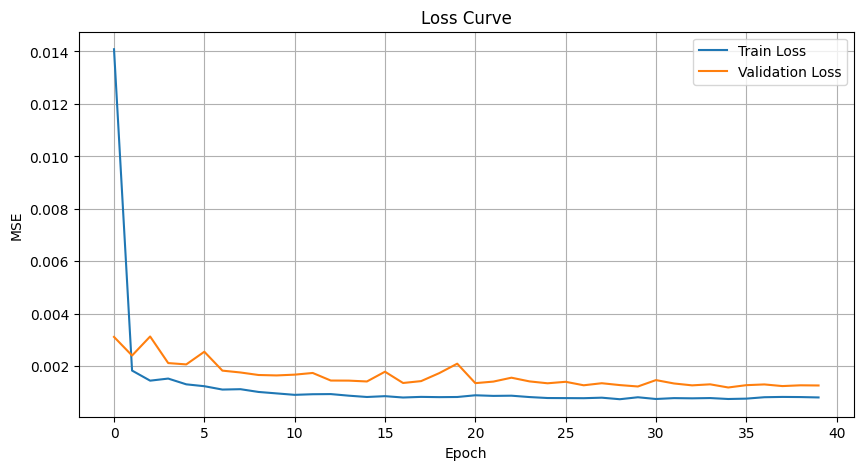

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()

plt.show()

## 7. Tạo dữ liệu Test (1-9/6)

In [ ]:
combined_df = pd.concat([train_df.tail(24),test_df])

combined_scaled = scaler.transform(
    combined_df[["Temperature"]]
)

X_test = []
Y_test = []

for i in range(TIME_STEPS,len(combined_scaled)):
    X_test.append(combined_scaled[i-TIME_STEPS:i,0])
    Y_test.append(combined_scaled[i,0])

X_test = np.array(X_test)
Y_test = np.array(Y_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_test: (216, 24, 1)
Y_test: (216,)


## 8. Dự đoán và đánh giá mô hình

In [ ]:
pred_scaled = model.predict(X_test)

predictions = scaler.inverse_transform(pred_scaled)

actual = scaler.inverse_transform(Y_test.reshape(-1,1))

mae = mean_absolute_error(actual,predictions)

rmse = np.sqrt(mean_squared_error(actual,predictions))

r2 = r2_score(actual,predictions)

print("========== KẾT QUẢ ==========")

print(f"MAE  = {mae:.3f} °C")
print(f"RMSE = {rmse:.3f} °C")
print(f"R²   = {r2:.4f}")

print("========== 20 KẾT QUẢ ĐẦU TIÊN ==========")

result_df = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predictions.flatten()
})

print(
    result_df.head(20)
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
========== KẾT QUẢ ==========
MAE  = 0.486 °C
RMSE = 0.722 °C
R²   = 0.9151
========== 20 KẾT QUẢ ĐẦU TIÊN ==========
    Actual  Predicted
0     24.9  24.962471
1     25.5  24.870419
2     25.1  25.464909
3     24.9  24.860958
4     24.9  24.650366
5     25.0  24.711779
6     24.9  25.214819
7     25.4  25.627832
8     26.1  26.114719
9     28.0  26.450603
10    29.2  28.114658
11    30.0  29.360241
12    29.9  30.304207
13    30.2  30.145193
14    30.0  30.215666
15    30.0  29.693758
16    30.3  29.420439
17    29.9  29.459198
18    28.6  29.035837
19    27.5  27.738821


## 9. Biểu đồ so sánh dự đoán và thực tế

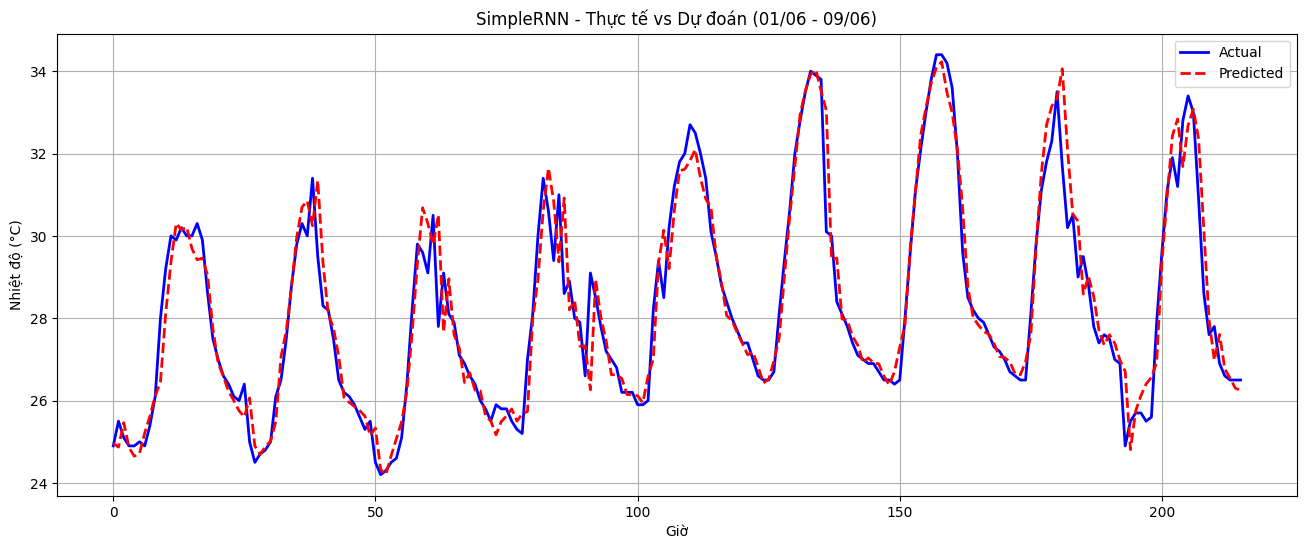

MAPE = 1.70%
Độ chính xác ≈ 98.30%


In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    actual,
    color="blue",
    linewidth=2,
    label="Actual"
)

plt.plot(
    predictions,
    "--",
    color="red",
    linewidth=2,
    label="Predicted"
)

plt.title(
    "SimpleRNN - Thực tế vs Dự đoán (01/06 - 09/06)"
)

plt.xlabel("Giờ")
plt.ylabel("Nhiệt độ (°C)")

plt.legend()
plt.grid()

plt.show()


mape = np.mean(np.abs((actual - predictions) / actual)) * 100

accuracy = 100 - mape

print(f"MAPE = {mape:.2f}%")

print(f"Độ chính xác ≈ {accuracy:.2f}%")

## 10. Giao diện

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Thiết kế CSS / HTML
title_html = """
<div style="background: linear-gradient(135deg, #4A00E0, #8E2DE2); padding: 20px; border-radius: 12px; color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; text-align: center; box-shadow: 0px 4px 10px rgba(0,0,0,0.2);">
    <h2 style="margin: 0; font-weight: 600; letter-spacing: 1.5px;">🌡️ HỆ THỐNG DỰ ĐOÁN NHIỆT ĐỘ AI (CUỐN CHIẾU)</h2>
    <p style="margin: 8px 0 0 0; font-size: 15px; opacity: 0.9;">Sử dụng mạng nơ-ron hồi quy SimpleRNN</p>
</div>
"""

instruction_html = """
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin-top: 15px; margin-bottom: 5px; color: #333;">
    <b>📋 Hướng dẫn:</b> Nhập vào 24 giá trị nhiệt độ của 24 giờ gần nhất, sau đó chọn số giờ muốn dự đoán vào tương lai.
</div>
"""

header_widget = widgets.HTML(value=title_html)
instruction_widget = widgets.HTML(value=instruction_html)

# Ô nhập dữ liệu
default_vals = "28.5, 28.2, 27.9, 27.5, 27.1, 26.8, 26.5, 27.0, 28.5, 30.1, 31.5, 32.8, 33.5, 34.0, 33.8, 33.0, 32.2, 31.0, 29.8, 29.0, 28.5, 28.1, 27.8, 27.5"
input_text = widgets.Textarea(
    value=default_vals,
    layout=widgets.Layout(width='100%', height='80px', border='1px solid #8E2DE2')
)

# THANH KÉO (SLIDER) MỚI ĐỂ CHỌN SỐ GIỜ DỰ ĐOÁN
steps_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=10,
    step=1,
    description='⏳ Số giờ tới:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px', margin='10px 0 10px 0')
)

predict_button = widgets.Button(
    description='🚀 THỰC HIỆN DỰ ĐOÁN',
    button_style='info',
    layout=widgets.Layout(width='250px', height='45px', margin='5px 0 15px 0')
)

output_area = widgets.Output()

# 2. Hàm xử lý logic dự đoán cuốn chiếu
def on_predict_clicked(b):
    with output_area:
        clear_output(wait=True)
        try:
            # Lấy chuỗi nhập vào
            raw_text = input_text.value
            original_vals = [float(x.strip()) for x in raw_text.split(',')]

            if len(original_vals) != TIME_STEPS:
                print(f"⚠️ LỖI: Mô hình yêu cầu đúng {TIME_STEPS} giá trị đầu vào. Bạn đang nhập {len(original_vals)} giá trị.")
                return

            num_future_steps = steps_slider.value
            current_input = original_vals.copy()
            predicted_vals = []

            # Vòng lặp dự đoán cuốn chiếu
            for _ in range(num_future_steps):
                # Luôn lấy 24 giá trị cuối cùng trong mảng current_input
                window = current_input[-TIME_STEPS:]

                input_df = pd.DataFrame(window, columns=['Temperature'])
                input_scaled = scaler.transform(input_df[['Temperature']])
                X_pred = input_scaled.reshape(1, TIME_STEPS, 1)

                # Dự đoán
                pred_scaled = model.predict(X_pred, verbose=0)
                pred_final = scaler.inverse_transform(pred_scaled)[0][0]

                # Lưu lại kết quả và nhét ngược vào current_input để đoán bước tiếp
                predicted_vals.append(pred_final)
                current_input.append(pred_final)

            # --- TẠO KHUNG KẾT QUẢ HTML ---
            # In ra danh sách các giờ dự đoán
            list_html = ""
            for i, p in enumerate(predicted_vals):
                list_html += f"<li style='margin-bottom: 5px;'>Dự đoán giờ thứ {24 + i + 1}: <b style='color: #E53E3E;'>{p:.2f} °C</b></li>"

            result_html = f"""
            <div style="padding: 15px; background-color: #F0FFF4; border-left: 6px solid #38A169; border-radius: 8px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0px 2px 5px rgba(0,0,0,0.05);">
                <h3 style="margin: 0 0 10px 0; color: #276749;">✅ KẾT QUẢ DỰ ĐOÁN ({num_future_steps} GIỜ TỚI)</h3>
                <ul style="font-size: 16px; color: #2D3748; margin: 0; padding-left: 20px;">
                    {list_html}
                </ul>
            </div>
            """
            display(widgets.HTML(value=result_html))

            # --- VẼ BIỂU ĐỒ (TIẾNG VIỆT KHÔNG DẤU) ---
            plt.style.use('seaborn-v0_8-whitegrid')
            fig, ax = plt.subplots(figsize=(12, 5))

            # Vẽ đường dữ liệu lịch sử
            ax.plot(range(1, 25), original_vals, marker='o', linestyle='-', color='#4A00E0', linewidth=2.5, markersize=6, label='Lich su (24 gio)')

            # Vẽ đường dự đoán tương lai
            future_x = range(25, 25 + num_future_steps)

            # Nối điểm cuối của lịch sử với điểm đầu của dự đoán cho liền mạch
            ax.plot([24, 25], [original_vals[-1], predicted_vals[0]], linestyle='--', color='#E53E3E', linewidth=2.5)

            # Vẽ các điểm dự đoán
            if num_future_steps > 1:
                ax.plot(future_x, predicted_vals, linestyle='--', color='#E53E3E', linewidth=2.5)
            ax.scatter(future_x, predicted_vals, color='#E53E3E', s=120, zorder=5, label='Du doan tuong lai', edgecolor='white', linewidth=1.5)

            # Trang trí
            ax.set_title("BIEU DO TRUC QUAN HOA CHUOI THOI GIAN VA DU DOAN", fontsize=14, fontweight='bold', pad=15, color='#333')
            ax.set_xlabel("Truc thoi gian (Gio)", fontsize=11, fontweight='bold')
            ax.set_ylabel("Nhiet do (°C)", fontsize=11, fontweight='bold')

            # Ẩn viền trên và phải
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)

            plt.tight_layout()
            plt.show()

        except ValueError:
            print("⚠️ LỖI: Định dạng không hợp lệ! Vui lòng chỉ nhập số và dấu phẩy.")
        except NameError as e:
            print(f"⚠️ LỖI: {e}. Đảm bảo đã chạy các ô huấn luyện phía trên.")

predict_button.on_click(on_predict_clicked)

# Hiển thị UI tổng hợp
ui_container = widgets.VBox([header_widget, instruction_widget, input_text, steps_slider, predict_button, output_area])
display(ui_container)